In [ ]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Step 1: Load and Explore the Data

Import Necessary Libraries:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [ ]:
file_path = '/content/drive/MyDrive/iphone_reviews.xlsx'
df = pd.read_excel(file_path)

##EDA

In [ ]:
print(df.head(3))

  productAsin country       date  isVerified  ratingScore              reviewTitle  \
0  B09G9BL5CP   India 2024-08-11        True            4               No charger   
1  B09G9BL5CP   India 2024-08-16        True            5          iPhone 13 256GB   
2  B09G9BL5CP   India 2024-05-14        True            4  Flip camera option nill   

                                   reviewDescription    Colors   Sizes  
0  Every thing is good about iPhones, there's not...  Midnight  256 GB  
1  It look so fabulous, I am android user switche...  Midnight  256 GB  
2  I tried to flip camera while recording but no ...  Midnight  256 GB  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3062 entries, 0 to 3061
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   productAsin        3062 non-null   object        
 1   country            3062 non-null   object        
 2   date               3062 non-null   datetime64[ns]
 3   isVerified         3062 non-null   bool          
 4   ratingScore        3062 non-null   int64         
 5   reviewTitle        3062 non-null   object        
 6   reviewDescription  2975 non-null   object        
 7   Colors             3062 non-null   object        
 8   Sizes              3062 non-null   object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(6)
memory usage: 194.5+ KB


Check for missing values

In [ ]:
print(df.isnull().sum())
#Null values in reviewDescription Found but we wont delete it as for these reviews reviewTitle is present and later on we will combine these two columns

productAsin           0
country               0
date                  0
isVerified            0
ratingScore           0
reviewTitle           0
reviewDescription    87
Colors                0
Sizes                 0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3062 entries, 0 to 3061
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   productAsin        3062 non-null   object        
 1   country            3062 non-null   object        
 2   date               3062 non-null   datetime64[ns]
 3   isVerified         3062 non-null   bool          
 4   ratingScore        3062 non-null   int64         
 5   reviewTitle        3062 non-null   object        
 6   reviewDescription  2975 non-null   object        
 7   Colors             3062 non-null   object        
 8   Sizes              3062 non-null   object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(6)
memory usage: 194.5+ KB


In [ ]:
#information of unique values of features
df.apply(lambda x: [x.nunique(), x.unique()]).T

,0,1
productAsin,7,"[B09G9BL5CP, B09P82T3PZ, B09G9J5JZX, B0CHX1W1X..."
country,7,"[India, Japan, United Arab Emirates, Egypt, Un..."
date,789,"[2024-08-11 00:00:00, 2024-08-16 00:00:00, 202..."
isVerified,2,"[True, False]"
ratingScore,5,"[4, 5, 3, 2, 1]"
reviewTitle,2018,"[No charger, iPhone 13 256GB, Flip camera opti..."
reviewDescription,2296,"[Every thing is good about iPhones, there's no..."
Colors,9,"[Midnight, Pink, Blue, Green, Starlight, Red, ..."
Sizes,3,"[256 GB, 128 GB, 512 GB]"


In [ ]:
#print the min and max dates
print("Max Date: ", df['date'].max())
print("Min Date: ", df['date'].min())
print("Period: ", df['date'].max() - df['date'].min())

Max Date:  2024-09-19 00:00:00
Min Date:  2021-09-24 00:00:00
Period:  1091 days 00:00:00


Interpretation

1. 7 countries the iphone variants reviewed
2. There are 9 colors and 3 size(storage) of phone
3. The reviews are in period from Fall 2021 to Fall 2024

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3062 entries, 0 to 3061
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   productAsin        3062 non-null   object        
 1   country            3062 non-null   object        
 2   date               3062 non-null   datetime64[ns]
 3   isVerified         3062 non-null   bool          
 4   ratingScore        3062 non-null   int64         
 5   reviewTitle        3062 non-null   object        
 6   reviewDescription  2975 non-null   object        
 7   Colors             3062 non-null   object        
 8   Sizes              3062 non-null   object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(6)
memory usage: 194.5+ KB


In [ ]:
#Fetch isVerified column unique values
print(df['isVerified'].unique())

#Print how many false values are there
print(df['isVerified'].value_counts())

[ True False]
isVerified
True     2850
False     212
Name: count, dtype: int64


Country wise distribution for verified and Unverified reviews

isVerified            False   True 
country                            
Canada                  NaN     4.0
Egypt                   NaN     1.0
India                 197.0  2032.0
Japan                   3.0   155.0
Mexico                  NaN    11.0
United Arab Emirates    4.0    76.0
United States           8.0   571.0


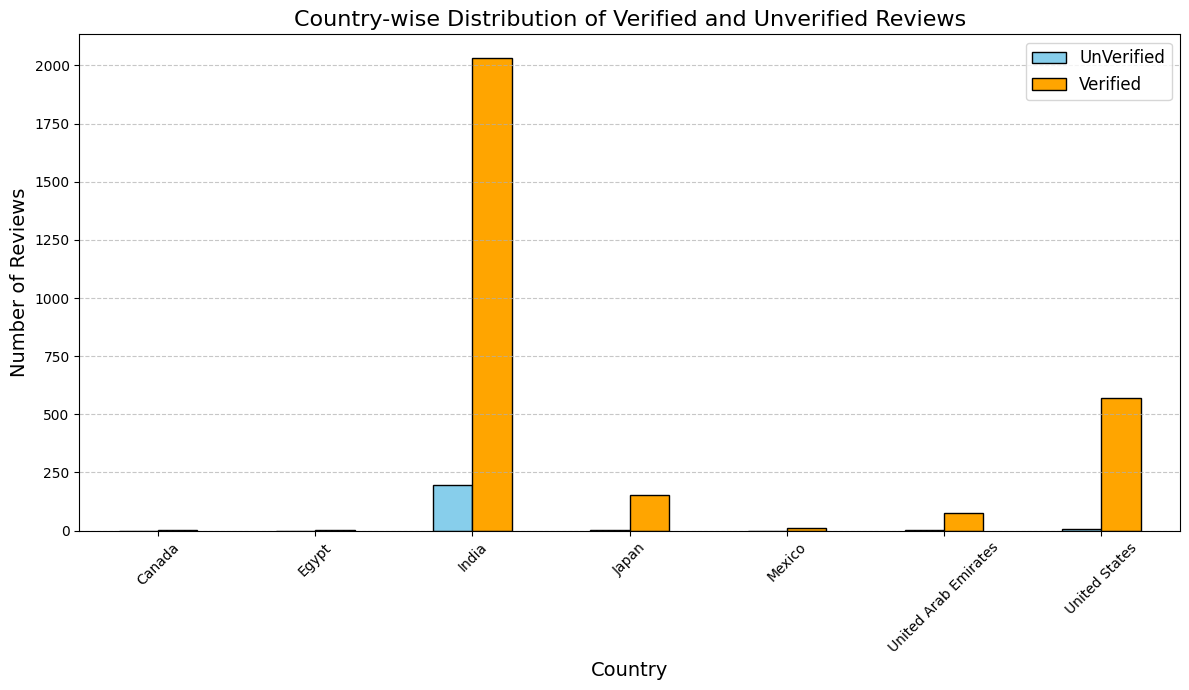

In [ ]:
# Group by 'country' and 'isVerified' and count the number of reviews
country_verified = df.groupby(['country', 'isVerified']).size().unstack()
print(country_verified)

# Plot the grouped bar chart
country_verified.plot(kind='bar', figsize=(12, 7), color=['skyblue', 'orange'], edgecolor='black')

# Add labels and title
plt.title('Country-wise Distribution of Verified and Unverified Reviews', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)
plt.xticks(rotation=45)
plt.legend(['UnVerified', 'Verified'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

After looking at the above graph, it is visible that %ge of False alerts is too low. Checking the Percentage and take a decision to delete or not.

In [ ]:
# Calculate the total number of reviews
total_reviews = len(df)

# Count the number of verified (True) and non-verified (False) reviews
verified_counts = df['isVerified'].value_counts()

# Calculate the percentage
verified_percentage = (verified_counts[True] / total_reviews) * 100
non_verified_percentage = (verified_counts[False] / total_reviews) * 100

# Print the results
print(f"Percentage of Verified Reviews (True): {verified_percentage:.2f}%")
print(f"Percentage of Non-Verified Reviews (False): {non_verified_percentage:.2f}%")

Percentage of Verified Reviews (True): 93.08%
Percentage of Non-Verified Reviews (False): 6.92%


Approxmately 7% of the reviews are not verfied. We will remove this since this not not a big number

In [ ]:
# Filteing the dataframe to keep only verified reviews
verified_reviews = df[df['isVerified'] == True]

# Check the result
print(f"Original number of reviews: {len(df)}")
print(f"Number of verified reviews: {len(verified_reviews)}")

# Display the first few rows of the filtered dataset
verified_reviews.head()

Original number of reviews: 3062
Number of verified reviews: 2850


,productAsin,country,date,isVerified,ratingScore,reviewTitle,reviewDescription,Colors,Sizes
0,B09G9BL5CP,India,2024-08-11,True,4,No charger,"Every thing is good about iPhones, there's not...",Midnight,256 GB
1,B09G9BL5CP,India,2024-08-16,True,5,iPhone 13 256GB,"It look so fabulous, I am android user switche...",Midnight,256 GB
2,B09G9BL5CP,India,2024-05-14,True,4,Flip camera option nill,I tried to flip camera while recording but no ...,Midnight,256 GB
3,B09G9BL5CP,India,2024-06-24,True,5,Product,100% genuine,Midnight,256 GB
4,B09G9BL5CP,India,2024-05-18,True,5,Good product,Happy to get the iPhone 13 in Amazon offer,Midnight,256 GB


#Country wise distribution of reviews

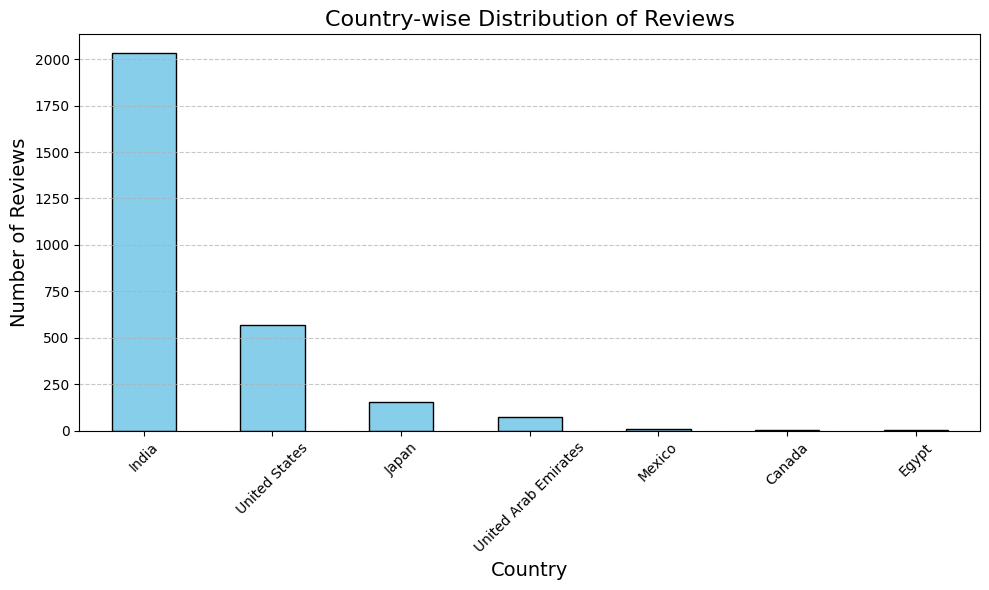

In [ ]:
# Group by 'country' and count the number of reviews
country_distribution = verified_reviews['country'].value_counts()

# Plot the distribution
plt.figure(figsize=(10, 6))
country_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Country-wise Distribution of Reviews', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

India and US are major contributors

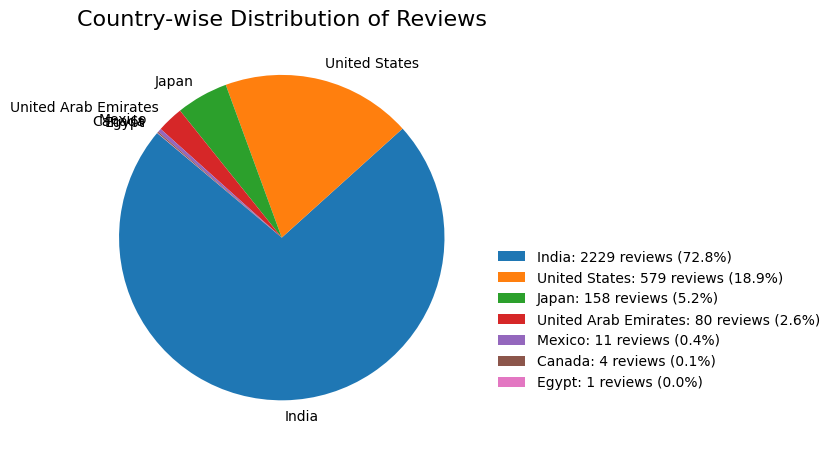

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming the data is already loaded into a DataFrame named df

# Count the number of reviews for each country
country_distribution = df['country'].value_counts()

# Calculate percentages for the legend
percentages = (country_distribution / country_distribution.sum()) * 100

# Plot the pie chart without percentages
plt.figure(figsize=(8, 8))
wedges, texts = plt.pie(
    country_distribution,
    labels=country_distribution.index,  # Keep labels or remove for a cleaner pie
    startangle=140,
    textprops={'fontsize': 10},
)

# Add title
plt.title('Country-wise Distribution of Reviews', fontsize=16)

# Use a legend to display country names, counts, and percentages
plt.legend(
    loc='upper left',
    labels=[
        f'{label}: {count} reviews ({percentage:.1f}%)'
        for label, count, percentage in zip(country_distribution.index, country_distribution, percentages)
    ],
    fontsize=10,
    bbox_to_anchor=(1, 0.5),  # Position the legend outside the chart
    frameon=False,
)

# Adjust layout
plt.tight_layout()
plt.show()

Average Rating per country

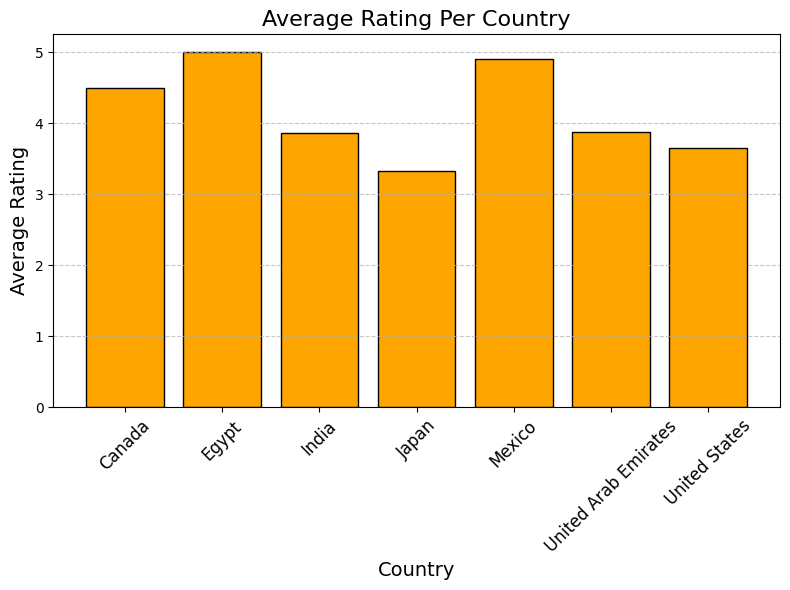

In [ ]:
# Group by country and calculate average rating
average_rating = verified_reviews.groupby('country')['ratingScore'].mean().reset_index()

# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.bar(
    average_rating['country'],
    average_rating['ratingScore'],
    color='orange',
    edgecolor='black',
)

# Add labels, title, and grid
plt.xlabel('Country', fontsize=14)
plt.ylabel('Average Rating', fontsize=14)
plt.title('Average Rating Per Country', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()



Interpretation

1. India has overall 3.8 rating to iPhone according to 2000+ reviews
2. United States has 3.7 rating from 500 reviews
3. Overall Globally 70% reviews >= than 4
4. India and US are major contributors of reviews

Exploring Variants

In [ ]:
# Create a new DataFrame by copying the filtered DataFrame
verified_reviews_copy = verified_reviews.copy()

# Create a new column that combines Color and Size
verified_reviews_copy['Variant'] = verified_reviews_copy['Colors'] + ' - ' + verified_reviews_copy['Sizes']

In [ ]:
verified_reviews_copy.head()

,productAsin,country,date,isVerified,ratingScore,reviewTitle,reviewDescription,Colors,Sizes,Variant
0,B09G9BL5CP,India,2024-08-11,True,4,No charger,"Every thing is good about iPhones, there's not...",Midnight,256 GB,Midnight - 256 GB
1,B09G9BL5CP,India,2024-08-16,True,5,iPhone 13 256GB,"It look so fabulous, I am android user switche...",Midnight,256 GB,Midnight - 256 GB
2,B09G9BL5CP,India,2024-05-14,True,4,Flip camera option nill,I tried to flip camera while recording but no ...,Midnight,256 GB,Midnight - 256 GB
3,B09G9BL5CP,India,2024-06-24,True,5,Product,100% genuine,Midnight,256 GB,Midnight - 256 GB
4,B09G9BL5CP,India,2024-05-18,True,5,Good product,Happy to get the iPhone 13 in Amazon offer,Midnight,256 GB,Midnight - 256 GB


In [ ]:
# Get unique phone combinations so we can analyse it further
unique_phones = verified_reviews_copy['Variant'].unique()

# Count of unique phones
unique_phone_count = len(unique_phones)
print(f'The number of unique phone combinations (Color and Size) is: {unique_phone_count}')
print('Unique phone combinations:')
print(unique_phones)

The number of unique phone combinations (Color and Size) is: 24
Unique phone combinations:
['Midnight - 256 GB' 'Pink - 256 GB' 'Blue - 256 GB' 'Green - 256 GB'
 'Pink - 128 GB' 'Starlight - 256 GB' 'Green - 128 GB'
 'Starlight - 128 GB' 'Midnight - 128 GB' 'Red - 128 GB' 'Blue - 128 GB'
 'Red - 256 GB' 'Starlight - 512 GB' 'Red - 512 GB' 'Midnight - 512 GB'
 'Pink - 512 GB' 'Blue - 512 GB' 'Yellow - 128 GB' 'Yellow - 256 GB'
 'Black - 128 GB' 'Black - 256 GB' 'Purple - 256 GB' 'Purple - 128 GB'
 'Purple - 512 GB']


##Rating Distribution

1. Overall Distribution
2. Country Wise Distribution
3. Model Wise Distribution

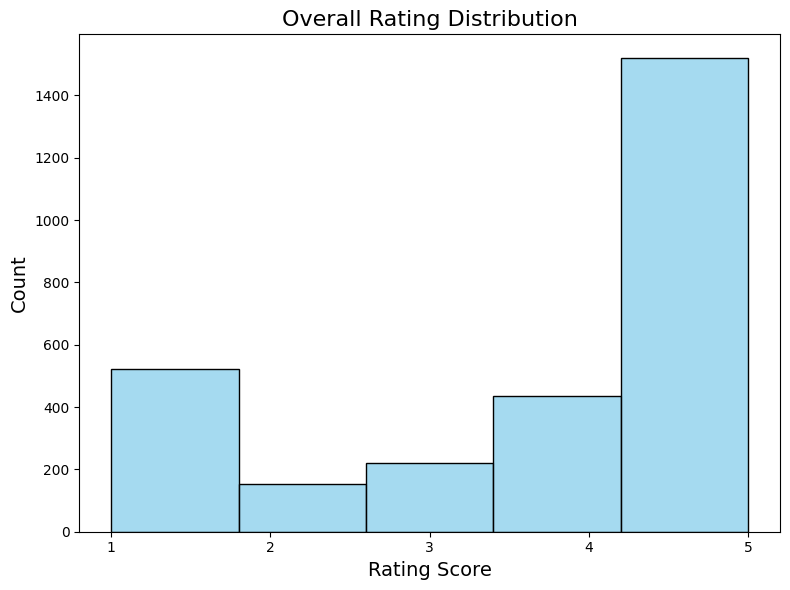

In [ ]:
#Overall Rating Distribution

# 1. Overall Rating Distribution
plt.figure(figsize=(8, 6))
sns.histplot(verified_reviews_copy['ratingScore'], bins=5, kde=False, color='skyblue')
plt.title('Overall Rating Distribution', fontsize=16)
plt.xlabel('Rating Score', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(range(1, 6))  # Ratings are typically between 1 and 5
plt.tight_layout()
plt.show()

Ratings are not fairly distributed.

1. Most ratings are 5
2. Followed by 1's - This is interesting because brands like Apple getting 1's
  is a matter of explore
3. Followed by 4's
4. 2's and 3's are the lowest.

2. Country wise Distrubution

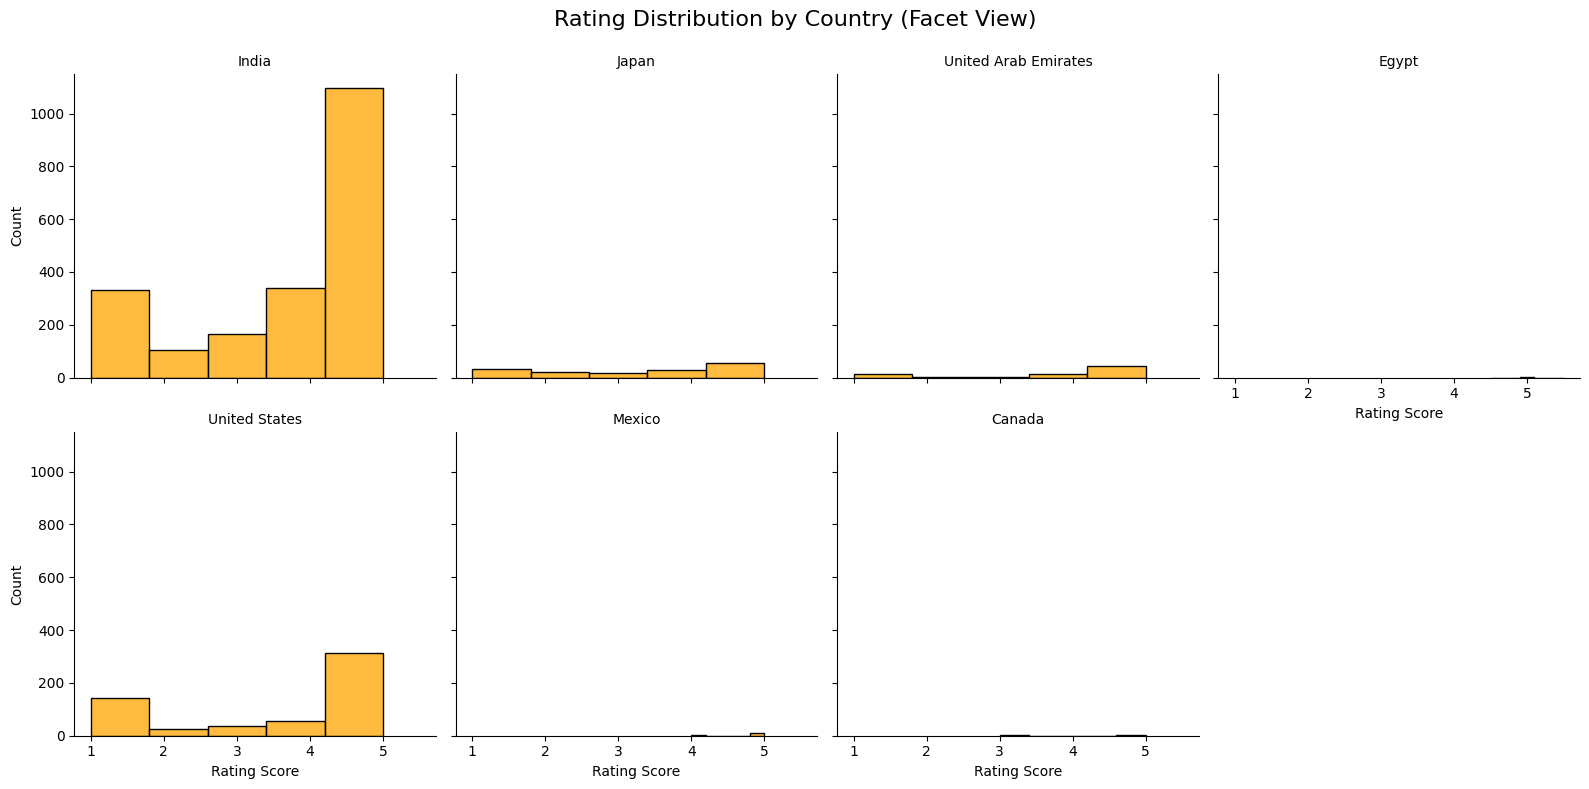

In [ ]:
# Rating distribution by country
g = sns.FacetGrid(verified_reviews_copy, col="country", col_wrap=4, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "ratingScore", bins=5, kde=False, color='orange')
g.set_titles("{col_name}")
g.set_axis_labels("Rating Score", "Count")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Rating Distribution by Country (Facet View)', fontsize=16)
plt.show()

In [ ]:
# Creating the pivot table to explore country wise distribution of ratings
pivot_table = pd.pivot_table(verified_reviews_copy,
                             index='country',    # Rows as Country
                             columns='ratingScore',   # Columns as Ratings
                             values='reviewTitle',  # Values as count of ratings (assuming reviewId is unique)
                             aggfunc='count',    # Counting the number of reviews for each country-rating combination
                             fill_value=0)       # Filling missing values with 0

# Printing the pivot table
print("Pivot Table: Country vs Ratings Count")
print(pivot_table)

Pivot Table: Country vs Ratings Count
ratingScore             1    2    3    4     5
country                                       
Canada                  0    0    1    0     3
Egypt                   0    0    0    0     1
India                 330  104  165  338  1095
Japan                  34   20   17   29    55
Mexico                  0    0    0    1    10
United Arab Emirates   15    2    4   12    43
United States         143   26   35   54   313


India is majorly distributed in 5's and somewhat in 4's & 1's but very little in 2's & 3's.

Japan has fairly distribution for all ratings.

UAE is 5's and few in 4's & 1's but megligible in 2's & 3's.

USA is majorly distributed in 5's followed by 1's and fairly diistrbuted in 2's, 3's & 4's.

Global distribution of variants reviews

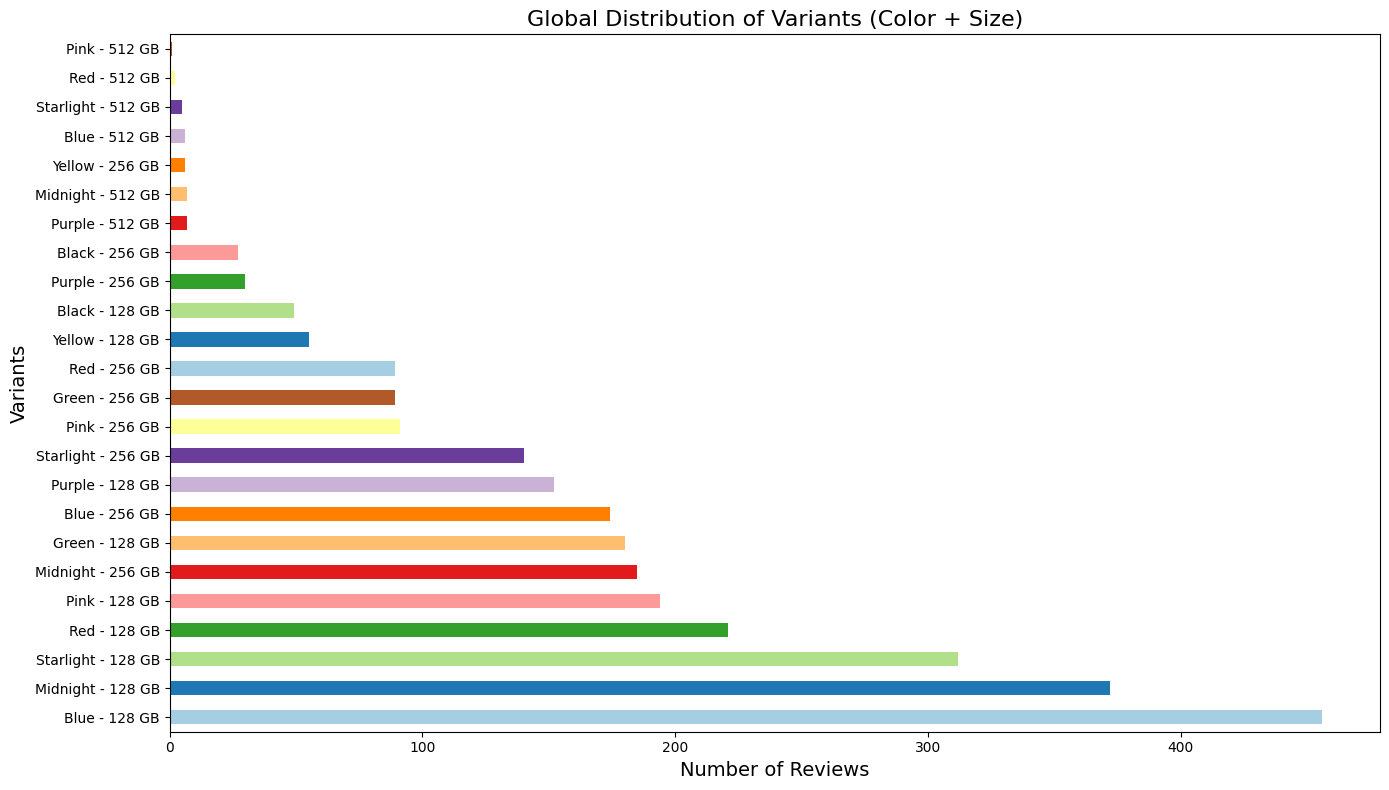

In [ ]:
# Plot horizontal bar chart for variant reviews distribution globally
variant_counts = verified_reviews_copy['Variant'].value_counts()

plt.figure(figsize=(14, 8))
variant_counts.plot(kind='barh', color=plt.cm.Paired.colors[:len(variant_counts)])
plt.title('Global Distribution of Variants (Color + Size)', fontsize=16)
plt.xlabel('Number of Reviews', fontsize=14)
plt.ylabel('Variants', fontsize=14)
plt.tight_layout()
plt.show()


Blue - 128GB has highest number of reviews followed by Midnight -128GB
Overall - Phones with 128GB s highly reviewed followed by 256 and then 512.



Country-wise distribution of variants reviews

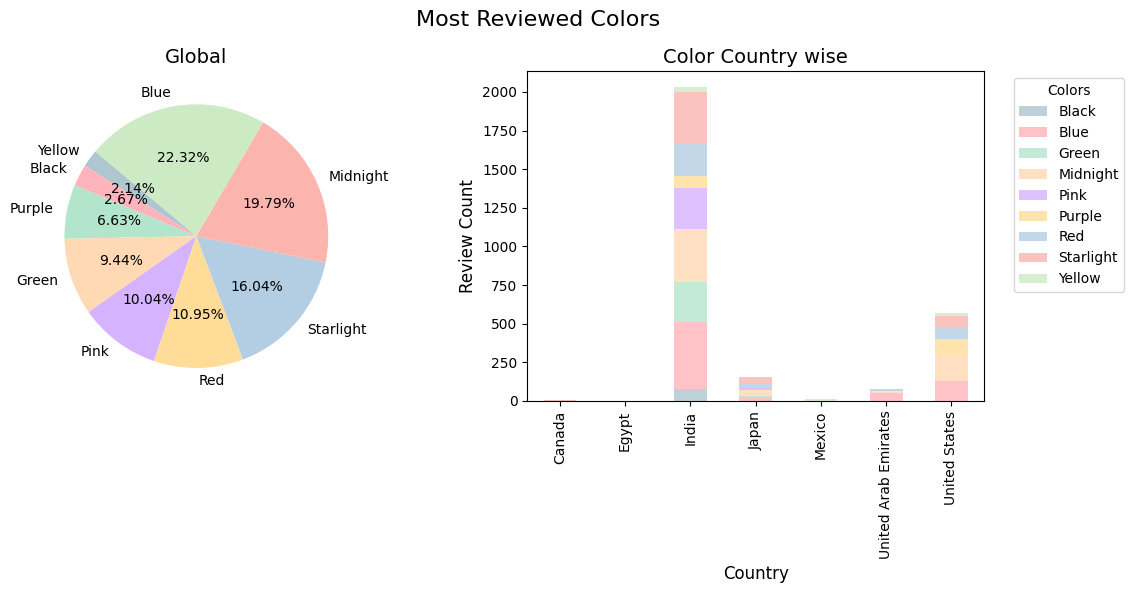

In [ ]:
from matplotlib.colors import to_rgba

# Define pastel color palette
colors_pastel = [
    '#aec6cf',  # Light Blue
    '#ffb3ba',  # Light Red
    '#b3e5cc',  # Light Green
    '#ffd9b3',  # Light Orange
    '#d5b3ff',  # Light Purple
    '#ffdd99',  # Light Yellow
    '#b3cde3',  # Light Cyan
    '#fbb4ae',  # Light Coral
    '#ccebc5',  # Light Mint
    '#decbe4',  # Light Lavender
]

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for global colors
g = verified_reviews_copy.groupby(by=['Colors'])['productAsin'].agg(['count'])
g['percentage'] = round(100 * g['count'] / verified_reviews_copy.shape[0], 2)
g = g.sort_values(by='percentage')
ax[0].pie(x=g.percentage, labels=g.index, autopct='%.2f%%', colors=colors_pastel[:len(g)], startangle=140)
ax[0].set_title("Global", fontsize=14)

# Stacked bar chart for country-wise colors
g = verified_reviews_copy.pivot_table(values='productAsin', index=['country'], aggfunc='count', columns='Colors', fill_value=0)
g.plot(kind='bar', stacked=True, ax=ax[1], color=[to_rgba(c, alpha=0.8) for c in colors_pastel[:g.shape[1]]])
ax[1].set_title("Color Country wise", fontsize=14)
ax[1].set_ylabel("Review Count", fontsize=12)
ax[1].set_xlabel("Country", fontsize=12)
ax[1].legend(title="Colors", bbox_to_anchor=(1.05, 1), loc='upper left')

# Overall layout adjustments
plt.suptitle("Most Reviewed Colors", fontsize=16)
plt.tight_layout()
plt.show()


Blue [22%] and [19%] Midnight is most reviewed colors in iphone Globally with combine 42% of share, followed by starlight [15%]

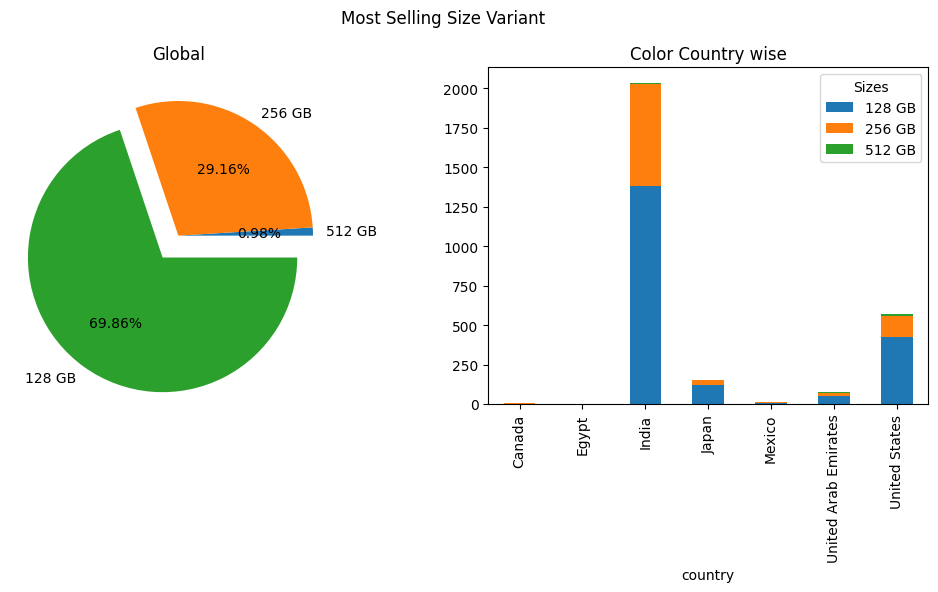

In [ ]:
#most reviewedcolor
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
g = verified_reviews.groupby(by=['Sizes'])['productAsin'].agg(['count'])
g['percentage'] = round(100*g['count']/verified_reviews.shape[0], 2)
g = g.sort_values(by='percentage')
ax[0].pie(x=g.percentage, labels=g.index, autopct='%.2f%%', explode=[0, 0, 0.2])
ax[0].set_title("Global")

#group by countries
g = verified_reviews.pivot_table(values='productAsin', index=['country'], aggfunc='count', columns='Sizes', fill_value=0)
g.plot(kind='bar', stacked=True, ax=ax[1], title="Color Country wise")

plt.suptitle("Most Selling Size Variant")
plt.tight_layout()
plt.show()

1. 128 GB is the most popular choice with 67.5% selling share globally

2. Followed by 256 GB variant with 31% market share

3. The choice of variant is same across countries [INDIA, USA]

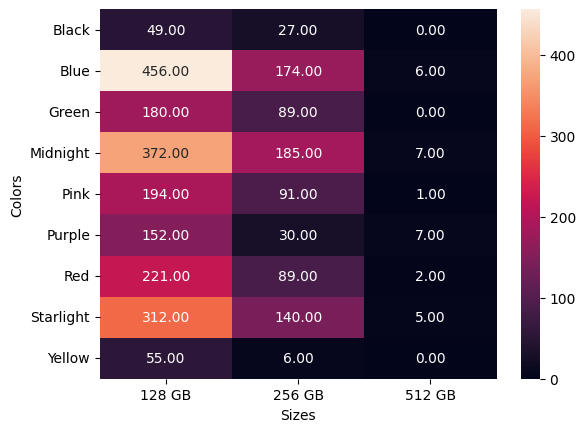

In [ ]:
g = verified_reviews.pivot_table(index=['Colors'], columns=['Sizes'], values=['productAsin'], aggfunc='count', fill_value=0)
sns.heatmap(g['productAsin'], annot=True, fmt='.2f')
plt.show()

1. 128GB variant is most popular with ['midnight', 'blue', 'starlight'] colors popular choice.

2. size 256 GB is less perfered than 128 GB but color choices remain same

3. 512 GB dont have much data ~ unpopular choice

##SENTIMENT ANALYSIS

##Extract Sentiment Labels using VADER

Using VADER to assign sentiment labels (Positive Negative) to the reviewDescription.

In [ ]:
#Making a copy of dataframe
iphone_reviews = verified_reviews_copy.copy()

In [ ]:
#Checking data types
iphone_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2850 entries, 0 to 3061
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   productAsin        2850 non-null   object        
 1   country            2850 non-null   object        
 2   date               2850 non-null   datetime64[ns]
 3   isVerified         2850 non-null   bool          
 4   ratingScore        2850 non-null   int64         
 5   reviewTitle        2850 non-null   object        
 6   reviewDescription  2776 non-null   object        
 7   Colors             2850 non-null   object        
 8   Sizes              2850 non-null   object        
 9   Variant            2850 non-null   object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(7)
memory usage: 225.4+ KB


In [ ]:
#concatenate reviewDescription and reviewTitle
iphone_reviews['reviewText'] = iphone_reviews['reviewTitle'].astype(str) + ' ' + iphone_reviews['reviewDescription'].astype(str)

In [ ]:
iphone_reviews.head()

,productAsin,country,date,isVerified,ratingScore,reviewTitle,reviewDescription,Colors,Sizes,Variant,reviewText
0,B09G9BL5CP,India,2024-08-11,True,4,No charger,"Every thing is good about iPhones, there's not...",Midnight,256 GB,Midnight - 256 GB,"No charger Every thing is good about iPhones, ..."
1,B09G9BL5CP,India,2024-08-16,True,5,iPhone 13 256GB,"It look so fabulous, I am android user switche...",Midnight,256 GB,Midnight - 256 GB,"iPhone 13 256GB It look so fabulous, I am andr..."
2,B09G9BL5CP,India,2024-05-14,True,4,Flip camera option nill,I tried to flip camera while recording but no ...,Midnight,256 GB,Midnight - 256 GB,Flip camera option nill I tried to flip camera...
3,B09G9BL5CP,India,2024-06-24,True,5,Product,100% genuine,Midnight,256 GB,Midnight - 256 GB,Product 100% genuine
4,B09G9BL5CP,India,2024-05-18,True,5,Good product,Happy to get the iPhone 13 in Amazon offer,Midnight,256 GB,Midnight - 256 GB,Good product Happy to get the iPhone 13 in Ama...


In [ ]:
#Drop review Title and review description column
iphone_reviews = iphone_reviews.drop(['reviewTitle', 'reviewDescription'], axis=1)

In [ ]:
iphone_reviews.head()

,productAsin,country,date,isVerified,ratingScore,Colors,Sizes,Variant,reviewText
0,B09G9BL5CP,India,2024-08-11,True,4,Midnight,256 GB,Midnight - 256 GB,"No charger Every thing is good about iPhones, ..."
1,B09G9BL5CP,India,2024-08-16,True,5,Midnight,256 GB,Midnight - 256 GB,"iPhone 13 256GB It look so fabulous, I am andr..."
2,B09G9BL5CP,India,2024-05-14,True,4,Midnight,256 GB,Midnight - 256 GB,Flip camera option nill I tried to flip camera...
3,B09G9BL5CP,India,2024-06-24,True,5,Midnight,256 GB,Midnight - 256 GB,Product 100% genuine
4,B09G9BL5CP,India,2024-05-18,True,5,Midnight,256 GB,Midnight - 256 GB,Good product Happy to get the iPhone 13 in Ama...


##Step 2: Assign Sentiment Scores

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.2 MB/s eta 0:00:00


In [ ]:
#import and initialise vader
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
#Create a function to assign sentiment labels
def get_sentiment(review):
    score = analyzer.polarity_scores(str(review))['compound']
    return 'Positive' if score > 0 else 'Negative'

In [ ]:
#Applying the function to the reviewDescription column
iphone_reviews['Sentiment'] = iphone_reviews['reviewText'].fillna('').apply(get_sentiment)

In [ ]:
iphone_reviews.head()

,productAsin,country,date,isVerified,ratingScore,Colors,Sizes,Variant,reviewText,Sentiment
0,B09G9BL5CP,India,2024-08-11,True,4,Midnight,256 GB,Midnight - 256 GB,"No charger Every thing is good about iPhones, ...",Negative
1,B09G9BL5CP,India,2024-08-16,True,5,Midnight,256 GB,Midnight - 256 GB,"iPhone 13 256GB It look so fabulous, I am andr...",Positive
2,B09G9BL5CP,India,2024-05-14,True,4,Midnight,256 GB,Midnight - 256 GB,Flip camera option nill I tried to flip camera...,Negative
3,B09G9BL5CP,India,2024-06-24,True,5,Midnight,256 GB,Midnight - 256 GB,Product 100% genuine,Negative
4,B09G9BL5CP,India,2024-05-18,True,5,Midnight,256 GB,Midnight - 256 GB,Good product Happy to get the iPhone 13 in Ama...,Positive


In [ ]:
print(iphone_reviews['Sentiment'].value_counts())

Sentiment
Positive    2048
Negative     802
Name: count, dtype: int64


<ipython-input-38-1b84656b1a57>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=iphone_reviews, x='Sentiment', palette='Set2')


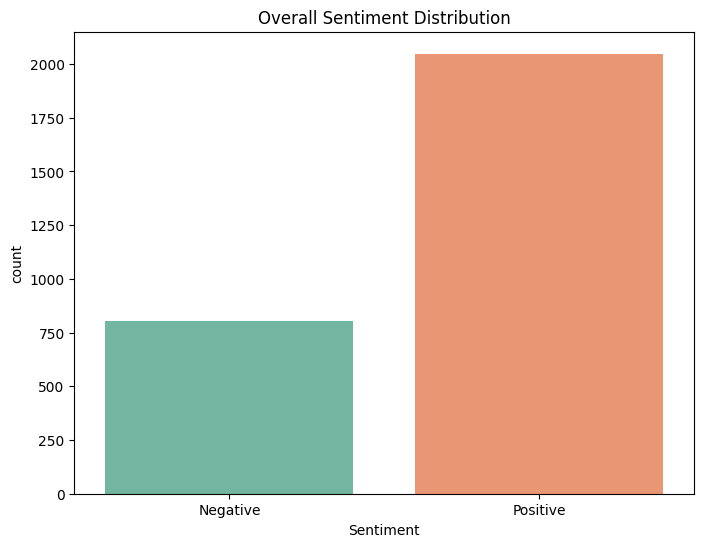

In [ ]:
# Plot overall sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=iphone_reviews, x='Sentiment', palette='Set2')
plt.title('Overall Sentiment Distribution')
plt.show()


In [ ]:
#print count of negative reviews by each country
print(iphone_reviews[iphone_reviews['Sentiment'] == 'Negative'].groupby('country').size())

#print total reviews per country
print(iphone_reviews.groupby('country').size())

country
Canada                    1
Egypt                     1
India                   559
Japan                    48
Mexico                    9
United Arab Emirates     14
United States           170
dtype: int64
country
Canada                     4
Egypt                      1
India                   2032
Japan                    155
Mexico                    11
United Arab Emirates      76
United States            571
dtype: int64


Dropping reviews for Canada and Egypt

In [ ]:
#Drop reviews posted for Egypt and Canada since very less reviews
iphone_reviews = iphone_reviews[~iphone_reviews['country'].isin(['Egypt', 'Canada'])]

In [ ]:
iphone_reviews.head()

,productAsin,country,date,isVerified,ratingScore,Colors,Sizes,Variant,reviewText,Sentiment
0,B09G9BL5CP,India,2024-08-11,True,4,Midnight,256 GB,Midnight - 256 GB,"No charger Every thing is good about iPhones, ...",Negative
1,B09G9BL5CP,India,2024-08-16,True,5,Midnight,256 GB,Midnight - 256 GB,"iPhone 13 256GB It look so fabulous, I am andr...",Positive
2,B09G9BL5CP,India,2024-05-14,True,4,Midnight,256 GB,Midnight - 256 GB,Flip camera option nill I tried to flip camera...,Negative
3,B09G9BL5CP,India,2024-06-24,True,5,Midnight,256 GB,Midnight - 256 GB,Product 100% genuine,Negative
4,B09G9BL5CP,India,2024-05-18,True,5,Midnight,256 GB,Midnight - 256 GB,Good product Happy to get the iPhone 13 in Ama...,Positive


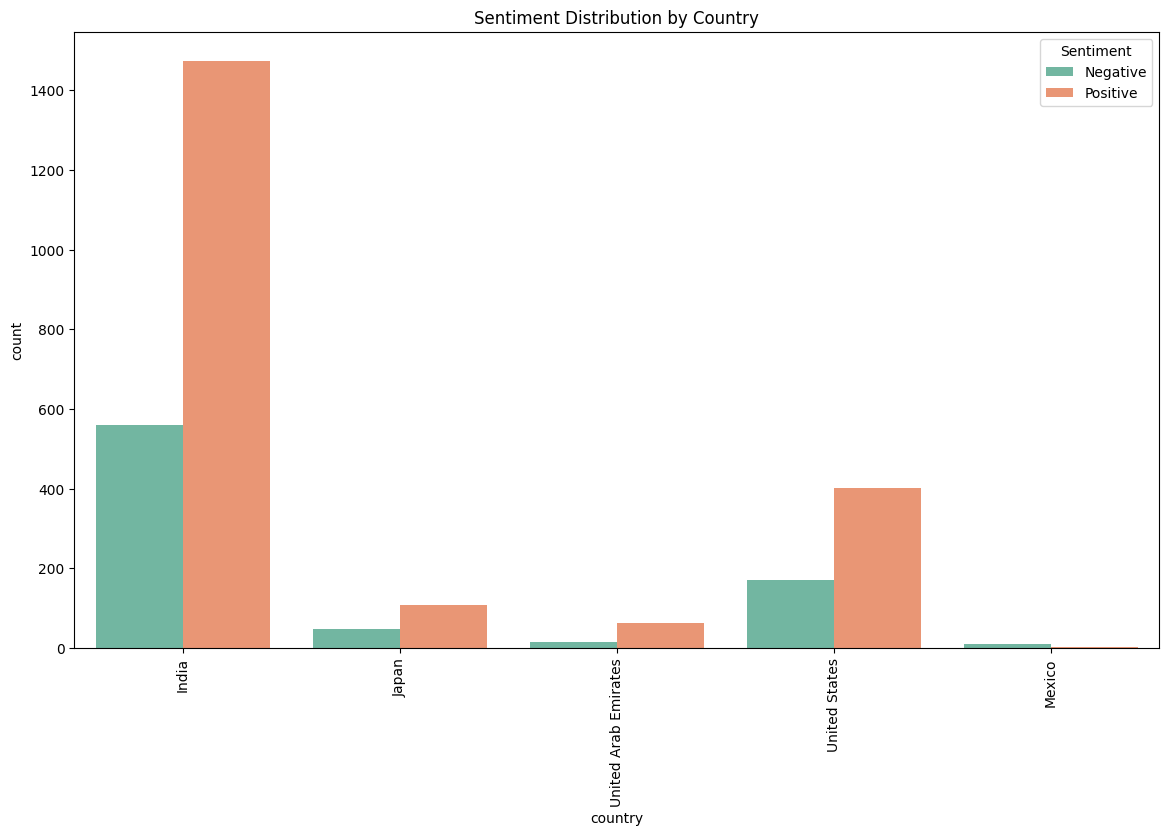

In [ ]:
# Plot sentiment distribution by country
plt.figure(figsize=(14, 8))
sns.countplot(data=iphone_reviews, x='country', hue='Sentiment', palette='Set2')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution by Country')
plt.show()

In [ ]:
#insights:
#Which country has the most positive reviews? UAE
#Which country has the most negative reviews? Mexico

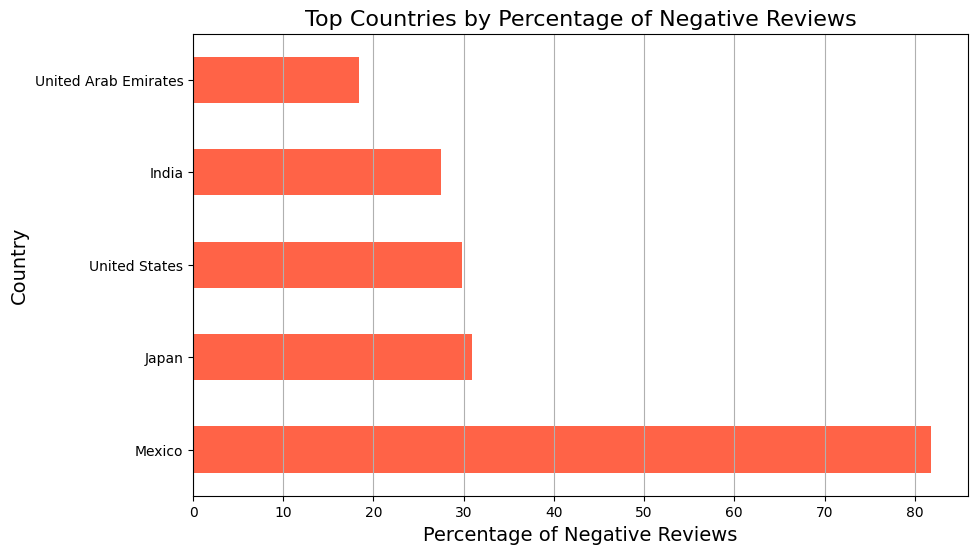

In [ ]:
#Top Countries by Negative Sentiment

#Identify countries with the highest proportion of negative reviews.
negative_sentiment = iphone_reviews[iphone_reviews['Sentiment'] == 'Negative'].groupby('country').size()
total_reviews = iphone_reviews.groupby('country').size()
negative_percentage = (negative_sentiment / total_reviews * 100).sort_values(ascending=False)

#plot
negative_percentage.plot(kind='barh', figsize=(10, 6), color='tomato')
plt.title('Top Countries by Percentage of Negative Reviews', fontsize=16)
plt.xlabel('Percentage of Negative Reviews', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.grid(axis='x')
plt.show()

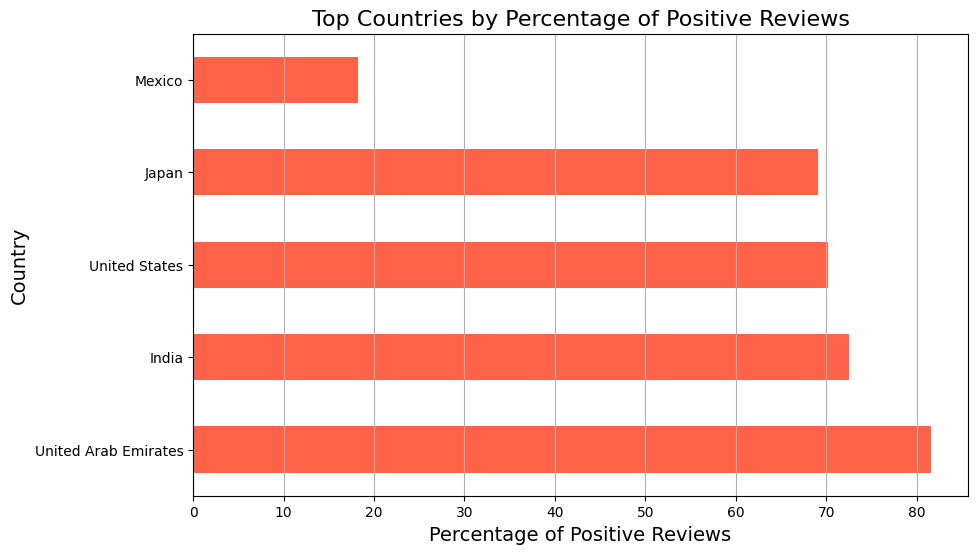

In [ ]:
#Top Countries by Positive Sentiment

#Identify countries with the highest proportion of positive reviews.
negative_sentiment = iphone_reviews[iphone_reviews['Sentiment'] == 'Positive'].groupby('country').size()
total_reviews = iphone_reviews.groupby('country').size()
negative_percentage = (negative_sentiment / total_reviews * 100).sort_values(ascending=False)

#plot
negative_percentage.plot(kind='barh', figsize=(10, 6), color='tomato')
plt.title('Top Countries by Percentage of Positive Reviews', fontsize=16)
plt.xlabel('Percentage of Positive Reviews', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.grid(axis='x')
plt.show()

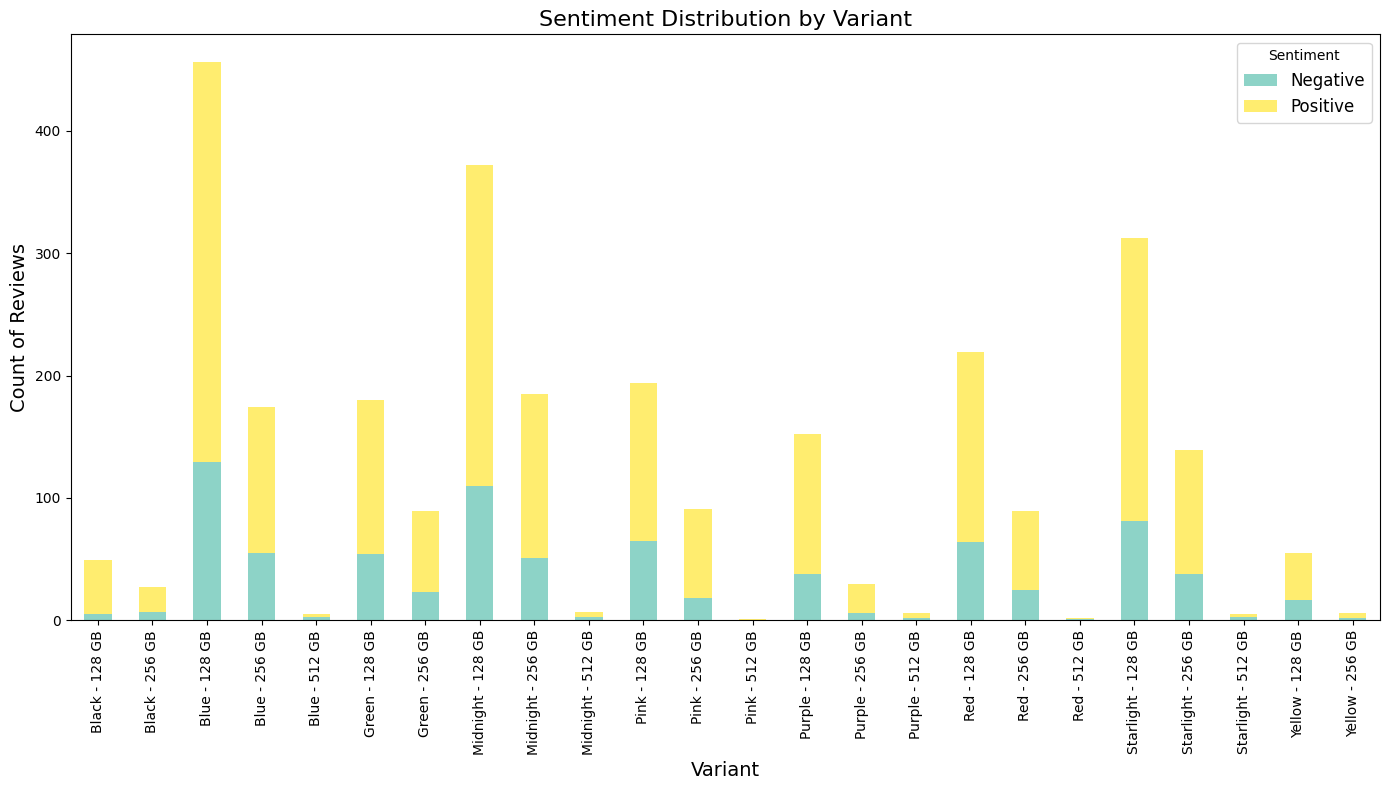

In [ ]:
#Sentiment Distribution by Variants
#Analyze which product variants (color + size) have the most positive, neutral, or negative reviews - See how to read
#Determine which variants receive the most negative feedback and whether specific features influence sentiment.

sentiment_by_variant = iphone_reviews.groupby(['Variant', 'Sentiment']).size().unstack(fill_value=0)

sentiment_by_variant.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Set3')
plt.title('Sentiment Distribution by Variant', fontsize=16)
plt.xlabel('Variant', fontsize=14)
plt.ylabel('Count of Reviews', fontsize=14)
plt.xticks(rotation=90)
plt.legend(title='Sentiment', fontsize=12)
plt.tight_layout()
plt.show()


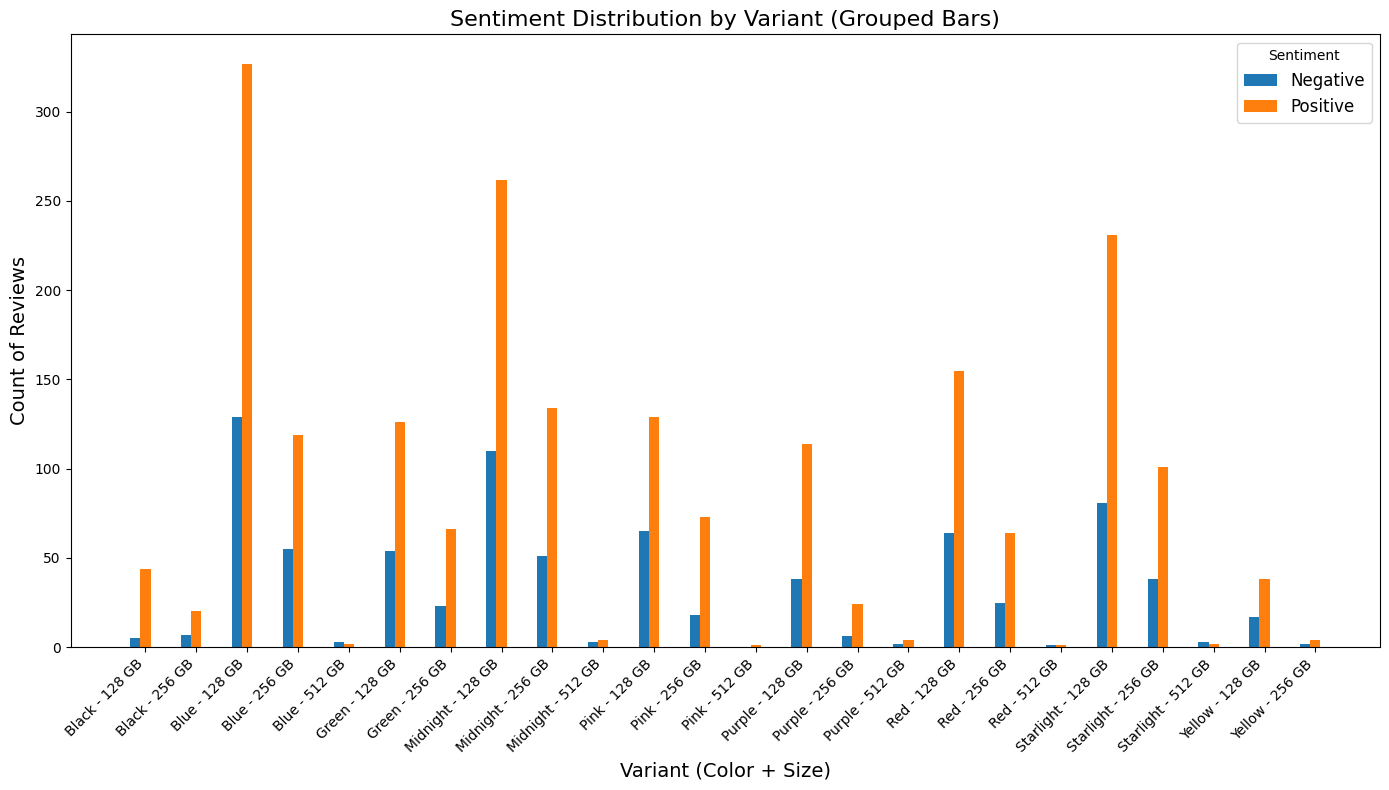

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Group data by Variant and Sentiment, then compute the counts
sentiment_by_variant = iphone_reviews.groupby(['Variant', 'Sentiment']).size().unstack(fill_value=0)

# Extract values for plotting
variants = sentiment_by_variant.index
sentiments = sentiment_by_variant.columns
counts = sentiment_by_variant.values

# Set up bar chart parameters
bar_width = 0.2  # Width of each bar
x_positions = np.arange(len(variants))  # Positions for each variant

# Plot each sentiment as a separate bar
plt.figure(figsize=(14, 8))
for i, sentiment in enumerate(sentiments):
    plt.bar(x_positions + i * bar_width, sentiment_by_variant[sentiment], width=bar_width, label=sentiment)

# Add labels, title, and legend
plt.xlabel('Variant (Color + Size)', fontsize=14)
plt.ylabel('Count of Reviews', fontsize=14)
plt.title('Sentiment Distribution by Variant (Grouped Bars)', fontsize=16)
plt.xticks(x_positions + bar_width, variants, rotation=45, ha='right')
plt.legend(title='Sentiment', fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

1. Some variants (e.g., Yellow - 128 GB, Red - 512 GB) have very few reviews,
   possibly due to low demand or availability issues.

2. Certain colors like Blue and Midnight consistently have high review counts,
   whereas colors like Yellow and Green are less reviewed.

3. Certain variants (e.g., Blue - 256 GB, Midnight - 256 GB) have significantly
  more reviews, indicating they are more popular among buyers.

4. Across most variants, positive reviews greatly outnumber negative reviews, suggesting overall customer satisfaction.

5. While negative sentiment is generally low, a few variants have more noticeable counts of negative reviews, such as Blue - 256 GB. These could warrant further investigation into specific complaints.

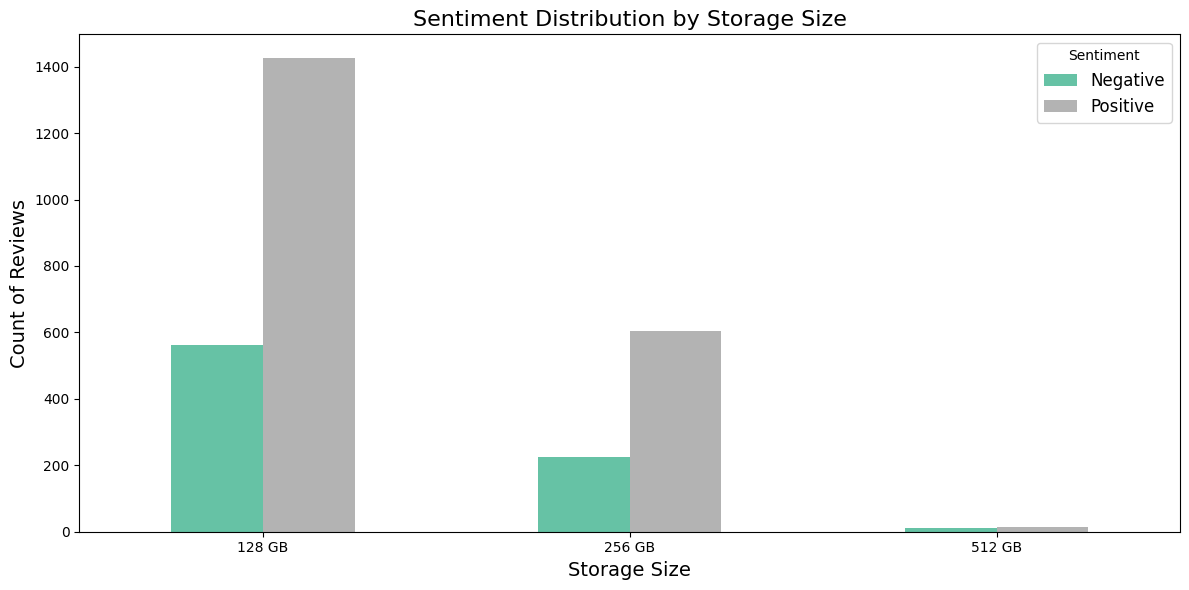

In [ ]:
# Group data by Storage Size and Sentiment
iphone_reviews['Storage Size'] = iphone_reviews['Variant'].str.extract(r'(\d+\s?GB)')
sentiment_by_storage = iphone_reviews.groupby(['Storage Size', 'Sentiment']).size().unstack(fill_value=0)

# Plot the sentiment distribution by storage size
sentiment_by_storage.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Sentiment Distribution by Storage Size', fontsize=16)
plt.xlabel('Storage Size', fontsize=14)
plt.ylabel('Count of Reviews', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

Sentiment distribution is mostly positive.

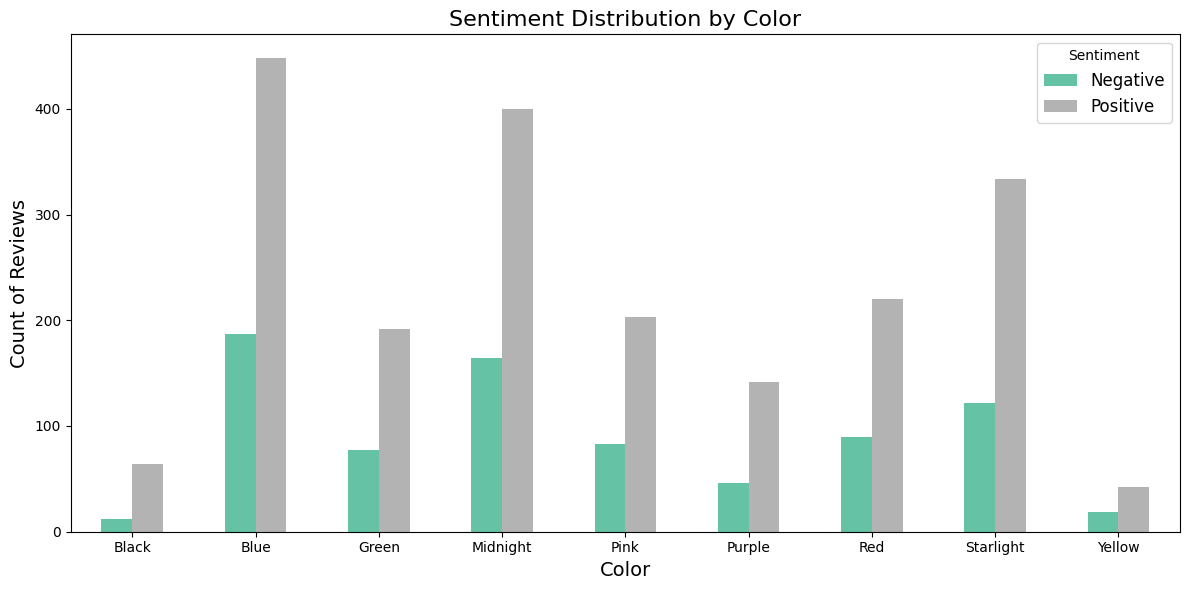

In [ ]:
# Group data by Storage Size and Sentiment
sentiment_by_color = iphone_reviews.groupby(['Colors', 'Sentiment']).size().unstack(fill_value=0)

# Plot the sentiment distribution by storage size
sentiment_by_color.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Sentiment Distribution by Color', fontsize=16)
plt.xlabel('Color', fontsize=14)
plt.ylabel('Count of Reviews', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

**WORLCLOUD Analysis**

In [ ]:
#Word Cloud for Positive and Negative Reviews
#Highlight common terms in positive and negative reviews.

!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

##Processing ReviewText for Text Modelling

Prepare text data for ML models by cleaning and tokenizing.

In [ ]:
pip install nltk scikit-learn

In [ ]:
#importing tools
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Clean the text data

In [ ]:
# Iterate and print each review
for review in iphone_reviews['reviewText']:
    print(review)

No charger Every thing is good about iPhones, there's nothing compared to it's speed and ios but i was disappointed because there's no charger for it even though Indian judiciary told them to provide , still they haven't made any progress regarding charger. Why should we spend 62k and more than that for iPhones because of it's brand and Acessories comfort size and Features right if that's not there what's point of buying an iPhone.Thank you🙏
iPhone 13 256GB It look so fabulous, I am android user switched to apple, performance wise iPhone is more better than android due to A15 Bionic chip. I feel pleasant while using iPhone in hand. I like it very much 😍❤️
Flip camera option nill I tried to flip camera while recording but no facility is added here. You have to pause first then you can flip from back to front or vice versa it means you can't continue it, very awkward position. Iphone software should be upgraded so that we can make it go. It's very essential for a content creator. I purch

In [ ]:
import re

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    tokens = text.split()  # Tokenize
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    return ' '.join(tokens)

iphone_reviews['cleaned_review'] = iphone_reviews['reviewText'].fillna('').apply(preprocess_text)

In [ ]:
# Iterate and print each review
for review in iphone_reviews['cleaned_review']:
    print(review)


charger every thing good iphones theres nothing compared speed ios disappointed theres charger even though indian judiciary told provide still havent made progress regarding charger spend k iphones brand acessories comfort size features right thats whats point buying iphonethank
iphone gb look fabulous android user switched apple performance wise iphone better android due bionic chip feel pleasant using iphone hand like much
flip camera option nill tried flip camera recording facility added pause first flip back front vice versa means cant continue awkward position iphone software upgraded make go essential content creator purchased gimbal dji om se could provided essential vlogger fed finding basic requirements wasnt built products
product genuine
good product happy get iphone amazon offer
smooth effective battery life star
apple gb great product nothing say name apple identity product well recommendation grab product else missed something
good good product
good nice product
excellent

Convert sentiment labels into numeric format

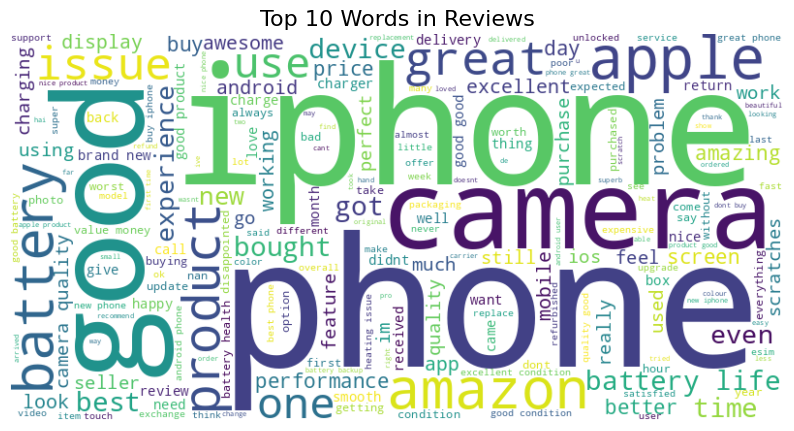

In [ ]:
# Combine all reviews into one large text
all_reviews = " ".join(iphone_reviews['cleaned_review'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 10 Words in Reviews", fontsize=16)
plt.show()

Positive and Negative reviews Word Cloud

Top 10 words in positive reviews:
[('phone', 1348), ('good', 1165), ('iphone', 1096), ('battery', 611), ('product', 520), ('camera', 494), ('great', 462), ('like', 357), ('apple', 350), ('new', 350), ('quality', 334), ('best', 324), ('amazon', 285), ('one', 271), ('android', 264)]

Top 10 words in negative reviews:
[('phone', 479), ('iphone', 271), ('battery', 212), ('product', 172), ('apple', 160), ('camera', 130), ('amazon', 126), ('buy', 114), ('good', 113), ('working', 97), ('quality', 97), ('bad', 94), ('screen', 83), ('issue', 74), ('android', 74), ('defective', 73), ('service', 72), ('even', 68), ('bought', 67), ('heating', 67)]


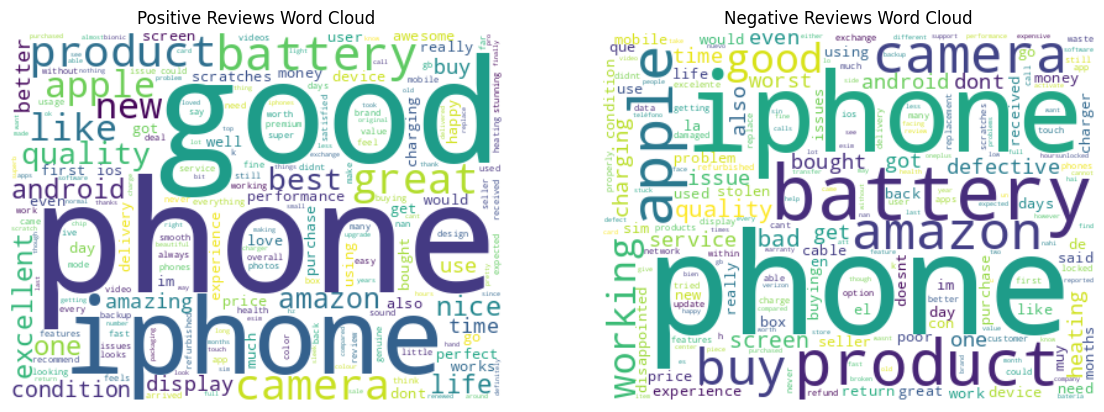

In [ ]:
from collections import Counter

positive_reviews = ' '.join(iphone_reviews[iphone_reviews['Sentiment'] == 'Positive']['cleaned_review'].dropna())
negative_reviews = ' '.join(iphone_reviews[iphone_reviews['Sentiment'] == 'Negative']['cleaned_review'].dropna())

# Separate positive and negative reviews
positive_reviews = iphone_reviews[iphone_reviews['Sentiment'] == 'Positive']['cleaned_review']
negative_reviews = iphone_reviews[iphone_reviews['Sentiment'] == 'Negative']['cleaned_review']

# Count words in positive reviews
positive_words = ' '.join(positive_reviews).split()
positive_word_counts = Counter(positive_words)

# Count words in negative reviews
negative_words = ' '.join(negative_reviews).split()
negative_word_counts = Counter(negative_words)

# Display top words for positive and negative sentiments
print("Top 10 words in positive reviews:")
print(positive_word_counts.most_common(15))

print("\nTop 10 words in negative reviews:")
print(negative_word_counts.most_common(20))

# Word Clouds for Positive and Negative Reviews
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
positive_wc = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(positive_word_counts)
negative_wc = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(negative_word_counts)

ax[0].imshow(positive_wc, interpolation='bilinear')
ax[0].axis('off')
ax[0].set_title('Positive Reviews Word Cloud')

ax[1].imshow(negative_wc, interpolation='bilinear')
ax[1].axis('off')
ax[1].set_title('Negative Reviews Word Cloud')

plt.show()

Insights

1. Reviews on **battery / Camera / Quality** are more **positive** than negative
2. We can see some **negative reviews** on related to **working**
3. There are **negative reviews on screen, heating and service**


##Feature Based Sentiment Analysis

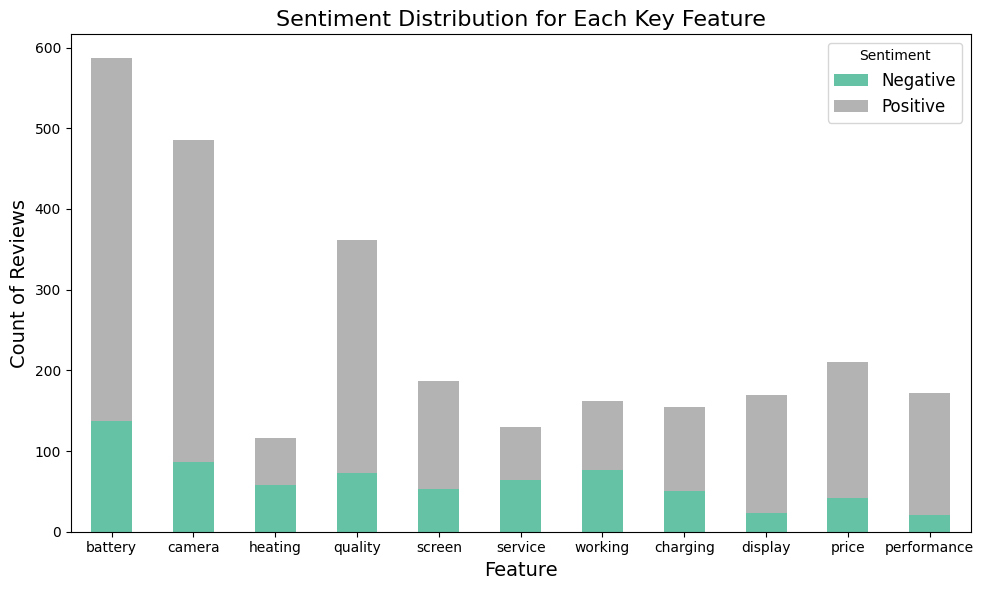

In [ ]:
# Define keywords for each feature
features = ['battery', 'camera', 'heating', 'quality','screen', 'service', 'working','charging','display','price','performance']

# Create a list to store sentiment distributions for each feature
sentiment_distribution = {}

# Loop through each feature and calculate the sentiment distribution
for feature in features:
    # Filter reviews containing the feature keyword (case insensitive)
    feature_reviews = iphone_reviews[iphone_reviews['cleaned_review'].str.contains(feature, case=False, na=False)]

    # Get sentiment counts for these reviews
    sentiment_counts = feature_reviews['Sentiment'].value_counts()

    # Store sentiment counts for each feature
    sentiment_distribution[feature] = sentiment_counts

# Convert sentiment_distribution dictionary to DataFrame for easier plotting
sentiment_df = pd.DataFrame(sentiment_distribution).T

# Plot the sentiment distribution as a bar chart
sentiment_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Sentiment Distribution for Each Key Feature', fontsize=16)
plt.xlabel('Feature', fontsize=14)
plt.ylabel('Count of Reviews', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

Insights

1. Service and phone working issue has mixed reviews, which company might need to check

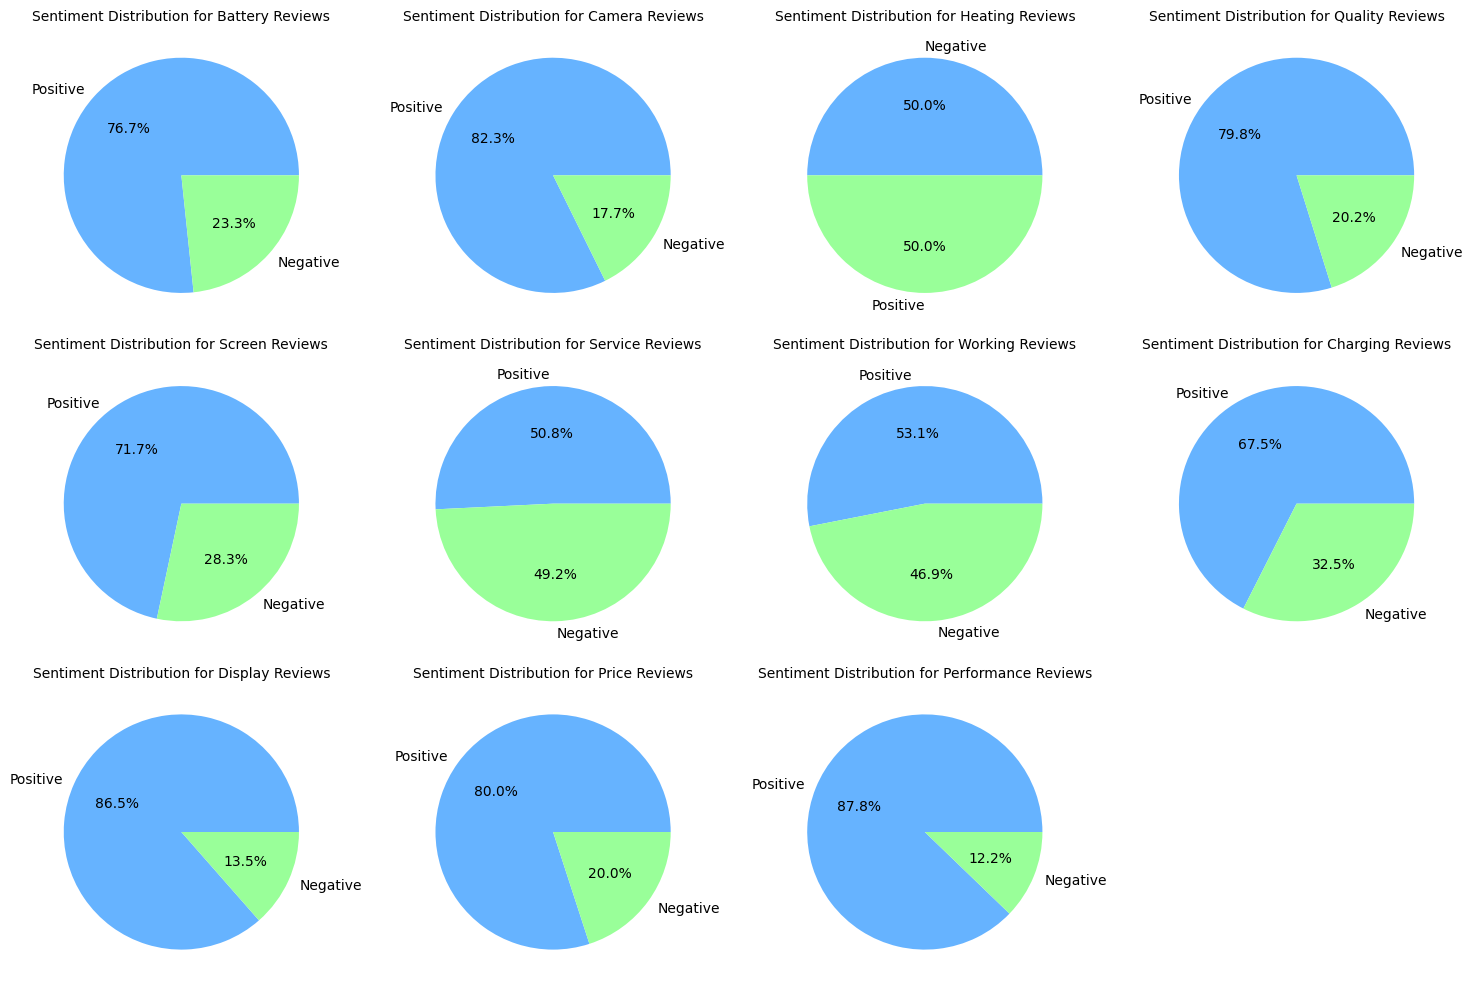

In [ ]:
# List of features you want to plot
features = ['battery', 'camera', 'heating', 'quality', 'screen', 'service', 'working', 'charging', 'display', 'price', 'performance']

# Set up the figure size for multiple plots
plt.figure(figsize=(15, 10))

# Loop through each feature and plot the pie chart
for i, feature in enumerate(features):
    # Filter reviews containing the feature
    feature_reviews = iphone_reviews[iphone_reviews['cleaned_review'].str.contains(feature, case=False, na=False)]

    # Get the sentiment counts for the feature reviews
    sentiment_counts_feature = feature_reviews['Sentiment'].value_counts()

    # Plot the pie chart for the feature
    plt.subplot(3, 4, i+1)  # 3 rows and 4 columns of plots
    plt.pie(sentiment_counts_feature, labels=sentiment_counts_feature.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
    plt.title(f'Sentiment Distribution for {feature.capitalize()} Reviews', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
label_encoder = LabelEncoder()
iphone_reviews['SentimentEncoded'] = label_encoder.fit_transform(iphone_reviews['Sentiment'])

In [ ]:
iphone_reviews.head()

,productAsin,country,date,isVerified,ratingScore,Colors,Sizes,Variant,reviewText,Sentiment,Storage Size,cleaned_review,SentimentEncoded
0,B09G9BL5CP,India,2024-08-11,True,4,Midnight,256 GB,Midnight - 256 GB,"No charger Every thing is good about iPhones, ...",Negative,256 GB,charger every thing good iphones theres nothin...,0
1,B09G9BL5CP,India,2024-08-16,True,5,Midnight,256 GB,Midnight - 256 GB,"iPhone 13 256GB It look so fabulous, I am andr...",Positive,256 GB,iphone gb look fabulous android user switched ...,1
2,B09G9BL5CP,India,2024-05-14,True,4,Midnight,256 GB,Midnight - 256 GB,Flip camera option nill I tried to flip camera...,Negative,256 GB,flip camera option nill tried flip camera reco...,0
3,B09G9BL5CP,India,2024-06-24,True,5,Midnight,256 GB,Midnight - 256 GB,Product 100% genuine,Negative,256 GB,product genuine,0
4,B09G9BL5CP,India,2024-05-18,True,5,Midnight,256 GB,Midnight - 256 GB,Good product Happy to get the iPhone 13 in Ama...,Positive,256 GB,good product happy get iphone amazon offer,1


#Trained Model

Divide data into training and testing sets.

In [ ]:
#Split Data
X = iphone_reviews['cleaned_review']
y = iphone_reviews['SentimentEncoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Convert text data into numerical format

##Using below for better result
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
#Train Model
#Train and evaluate a classification model

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
#import random forest classifier
from sklearn.ensemble import RandomForestClassifier
#import svm
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

#model = LogisticRegression()
#model = MultinomialNB()
model = SVC()
#model = RandomForestClassifier()
model.fit(X_train_vec, y_train)

SVC()

In [ ]:
#make predictions
y_pred = model.predict(X_test_vec)

Evaluate model

In [ ]:
#Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.875219683655536
Classification Report:
               precision    recall  f1-score   support

    Negative       0.85      0.67      0.75       157
    Positive       0.88      0.95      0.92       412

    accuracy                           0.88       569
   macro avg       0.86      0.81      0.83       569
weighted avg       0.87      0.88      0.87       569



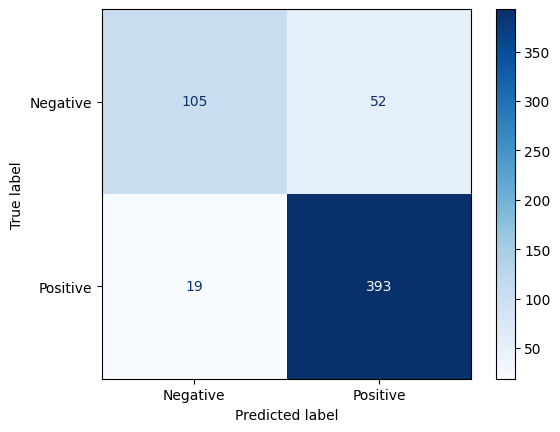

In [ ]:
#Display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test_vec, y_test, display_labels=label_encoder.classes_, cmap='Blues')
plt.show()